# Fundamentals of Data Science
## Week 3: Data Understanding

---

## Table of Contents
1. Learning Objectives
2. ทำไม Data Understanding สำคัญ
3. Data Types & Data Quality
4. Missing Data
5. Outliers
6. Bias  
7. Business Understanding ↔ Data Understanding
8. Hands-on Practice
9. Deliverable Checklist

---

# 1) Learning Objectives

เมื่อจบคาบนี้ นักศึกษาจะสามารถ

1. อธิบายความแตกต่างระหว่าง โครงสร้างข้อมูล กับ คุณภาพข้อมูล ได้อย่างชัดเจน
2. วิเคราะห์ปัญหาคุณภาพข้อมูล (missing, outlier, inconsistency, bias) จาก dataset
3. เชื่อมโยง Business Understanding ↔ Data Understanding

---

# 2) ทำไม Data Understanding สำคัญ

ใน CRISP-DM หลายคนมักเข้าใจผิดว่า

> “พอโหลดข้อมูลเข้า pandas แล้ว = เข้าใจข้อมูลแล้ว”

แต่ในทางปฏิบัติ **Data Understanding คือขั้นตอนที่ตอบคำถามว่า**

* ข้อมูลนี้ *เป็นตัวแทนของโลกจริงได้แค่ไหน*
* ข้อมูลนี้ *เหมาะกับคำถามทางธุรกิจที่ตั้งไว้หรือไม่*
* ข้อมูลนี้ *มีข้อจำกัดอะไรที่ต้องระวังก่อนทำ Modeling*

ถ้าเราข้ามขั้นตอนนี้ไป

* โมเดลอาจแม่น “ในเชิงตัวเลข” แต่ **ผิดในเชิงความหมาย**
* Insight ที่ได้อาจ **ชี้นำการตัดสินใจผิด**

---

# 3) Data Types & Data Quality

## 3.1 Data Types ที่พบบ่อยในงานจริง

| ประเภท      | ตัวอย่าง | ข้อควรระวัง           |
| ----------- | ----------------------- | --------------------- |
| Numerical   | price, quantity         | หน่วย, scale          |
| Categorical | drink_type, branch      | สะกดไม่สม่ำเสมอ       |
| Temporal    | order_time              | timezone, granularity |
| Identifier  | order_id                | ไม่ใช่ feature        |

*ประเด็นสำคัญ:*
> `dtype` ใน pandas คือ “รูปแบบการเก็บในหน่วยความจำ” (storage/computation)  
> แต่ *Semantic type* คือ “ความหมายจริง” และ “วิธีที่เราควรปฏิบัติกับมัน” (meaning/usage)

งาน Data Understanding คือการ “จัดหมวดความหมาย” ก่อน จากนั้นค่อย “เลือกวิธีจัดการ”

### 3.1.1 ทำไม `dtype` ถึงหลอกเราได้

**ตัวอย่าง:**

* คอลัมน์ `customer_id` เป็นตัวเลข → pandas อ่านเป็น `int64`  
  แต่ semantic จริงคือ **Identifier**  
  ถ้าเอาไปเข้าโมเดล มันจะ “ตีความเป็นตัวเลขที่มีลำดับ” ทั้งที่ไม่ควรมีลำดับ

* คอลัมน์ `zip_code` เป็นตัวเลข → pandas อ่านเป็น `int64`  
  แต่ semantic จริงคือ **Categorical/Location code**  
  และถ้าอ่านเป็น int จะทำให้ **เลขนำหน้า 0 หาย** (เช่น 01000 → 1000) กลายเป็นข้อมูลผิดทันที

* คอลัมน์ `order_time` เป็น string → pandas อ่านเป็น `object`  
  แต่ semantic จริงคือ **Temporal**  
  ถ้าไม่ parse เวลา จะทำ time-based analysis และ anomaly detection ไม่ได้

> pandas รู้จักชนิดข้อมูลเพื่อคำนวณ แต่ไม่รู้จักความหมาย  
> มนุษย์ต้องตีความ แล้วใช้คำสั่งให้ถูกต้อง

---

### 3.1.2 Semantic Data Types (ประเภทที่ใช้จริงใน DS)

#### (1) Identifier / Key

**ความหมาย:** ตัวระบุเอนทิตี/เหตุการณ์ ใช้เชื่อมโยง ไม่ใช่ค่าที่สื่อสารปริมาณ

**ตัวอย่าง:** `order_id`, `customer_id`, `device_id`

**ความเสี่ยงถ้าจัดการผิด:**
* เอาเข้าโมเดลตรง ๆ → โมเดล “จำ” (memorize) แทน “เรียนรู้”
* identifier บางตัว “เข้ารหัสความหมายแฝง” เช่น `branch_A12` อาจบอกภูมิภาค/ขนาดสาขา → ต้องระวังไม่ให้โมเดลเรียนรู้สิ่งที่ไม่ควรเรียนรู้

---

#### (2) Measure / Metric (Continuous numerical)

**ความหมาย:** ค่าที่วัด/คำนวณได้ต่อเนื่อง เช่น ปริมาณ ราคา อุณหภูมิ

**ตัวอย่าง:** `price`, `pm25`, `temperature`

**ความเสี่ยง:**
* หน่วยไม่เหมือนกัน (mg vs µg)
* scale ต่างกันทำให้โมเดล/สถิติหลอกได้
* sensor drift / rounding error

**สิ่งที่ควรถามใน Data Understanding:**
* “หน่วยคืออะไร”
* “ช่วงค่าที่เป็นไปได้ (valid range) คืออะไร”
* “ค่า 0 มีความหมายจริง หรือหมายถึง missing ที่เข้ารหัสผิด”

---

#### (3) Categorical (Nominal)

**ความหมาย:** หมวดหมู่ที่ “ไม่มีลำดับ”

**ตัวอย่าง:** `drink_type`, `payment_method`, `device_model`

**ความเสี่ยง:**
* สะกดไม่สม่ำเสมอ (Latte, latte, LATTE)
* หมวดใหม่โผล่ (new category)
* หมวดเดียวกันแต่หลาย label (done, finish, complete)

**ผลกระทบถ้าไม่จัดการให้ดี:**
* จำนวน category พุ่ง → one-hot พอง → model training ช้า
* สถิติ “นับจำนวน” เพี้ยน (เพราะแยกเป็นหลายชื่อ)

---

#### (4) Ordinal (Ordered categorical)

**ความหมาย:** หมวดหมู่ที่ “มีลำดับ” แต่ระยะห่างไม่เท่ากัน

**ตัวอย่าง:** `low/medium/high`, `satisfaction 1-5`

**ความเสี่ยง:**
* ถ้า encode ผิดเป็น one-hot อาจเสียข้อมูลลำดับ
* ถ้า treat เป็น numeric อาจแปลว่า “ระยะห่างเท่ากัน” ทั้งที่ไม่จริง

---

#### (5) Temporal (Time)

**ความหมาย:** เวลา/วันที่/ช่วงเวลา มีลำดับและความต่อเนื่อง

**ตัวอย่าง:** `timestamp`, `order_date`, `hour`

**ความเสี่ยง:**
* timezone mismatch
* daylight saving (บางประเทศ)
* ความละเอียดเวลาต่างกัน (minute vs hour vs day)
* missing เป็น “ช่วง” ทำให้ time-series analysis พัง

* เวลา “ไม่ใช่แค่คอลัมน์” แต่มันคือ “โครงสร้างของข้อมูล” (index/sequence)

---

#### (6) Spatial / Location

**ความหมาย:** ที่ตั้ง/ภูมิศาสตร์/พื้นที่

**ตัวอย่าง:** `lat`, `lon`, `district`, `zone`

**ความเสี่ยง:**
* พิกัดสลับ (lat/lon)
* geocoding ผิด
* หากใช้ location เป็น feature อาจเกิด bias/ความไม่เป็นธรรม (เช่น area-based discrimination)

---

#### (7) Text (Unstructured/Semi-structured)

**ความหมาย:** ข้อความอิสระ

**ตัวอย่าง:** `comment`, `issue_description`

**ความเสี่ยง:**
* ความยาวไม่เท่ากัน, ภาษา, สัญลักษณ์
* PII หลุดเข้ามา (ชื่อ-เบอร์โทร)

> แทนที่จะถาม “คอลัมน์นี้เป็น int หรือ float?”  
> ให้ถาม “คอลัมน์นี้ *มีหน้าที่* อะไรในระบบจริง?”

---

## 3.2 Data Quality Dimensions

<img src="https://kanerika.com/wp-content/uploads/2023/04/The-6-Core-Dimensions-of-Data-Quality-visual-selection.png"><br>

image from [What is Data Quality? Key Concepts and Importance](https://kanerika.com/blogs/data-quality/)

---

# 4) Missing Data

## 4.1 “Missing” ไม่ได้หมายถึง NaN อย่างเดียว

พบได้หลายรูปแบบ:

* `NaN`, `None`
* string เช่น `"N/A"`, `"null"`, `""`
* sentinel เช่น `-999`, `9999`, `0` (อันตรายมากเพราะดูเหมือนค่าจริง)
* “หายทั้งแถว” เพราะ join ไม่ติด

> ก่อนวิเคราะห์ missing ต้อง normalize รูปแบบ missing ให้เป็นมาตรฐาน

---

## 4.2 กลไกการเกิด Missing (MCAR / MAR / MNAR) และผลกระทบ

### (1) MCAR — Missing Completely At Random

**สาเหตุ:** network glitch แบบสุ่ม, sampling bug แบบสุ่ม

**ผลกระทบ:** ลดขนาดข้อมูล → ความแม่นยำลด แต่ bias ไม่รุนแรงเท่าแบบอื่น

**ความเสี่ยงถ้าจัดการไม่ดี:**
* drop แถวจนข้อมูลเหลือน้อย → สรุปไม่เสถียร

### (2) MAR — Missing At Random (สัมพันธ์กับตัวแปรอื่น)

**สาเหตุ:** หายเมื่อมีเงื่อนไขบางอย่าง เช่น ฝนหนัก → สัญญาณหาย

**ผลกระทบ:** ถ้าเติมแบบไม่สนเงื่อนไข → bias

**ความเสี่ยงถ้าจัดการไม่ดี:**
* ทำให้ความสัมพันธ์ (เช่น ระหว่างฝนกับค่าที่วัด) เพี้ยน

### (3) MNAR — Missing Not At Random (สัมพันธ์กับค่าของมันเอง)

**สาเหตุ:** sensor saturation, คนไม่กรอกเมื่อค่าจริง “น่าอาย/เสี่ยง”

**ผลกระทบ:** ซ่อนเหตุการณ์สำคัญ → ประเมินต่ำเกินจริง

**ความเสี่ยงถ้าจัดการไม่ดี:**
* สรุปว่า “ไม่มีเหตุการณ์รุนแรง” ทั้งที่จริง “ระบบไม่สามารถบันทึกได้”

---

## 4.3 สาเหตุที่พบบ่อยของ Missing Data (เชิงระบบงานจริง)

**A) Data Collection / Sensor Layer**

* อุปกรณ์เสีย / calibration เพี้ยน
* ไฟดับ / แบตหมด
* sensor warm-up ช่วงเริ่มต้นวัน
* ข้อจำกัดช่วงวัด (อ่านค่าสูง/ต่ำไม่ได้)

**ผลกระทบถ้าไม่จัดการดี**

* เหมือนเรา “ตาบอด” ในบางช่วงเวลา
* เกิด false conclusion เช่น “ช่วงนั้นอากาศดี” ทั้งที่จริงคือ “ไม่มีข้อมูล”

---

**B) Data Transmission / Network Layer**

* สัญญาณขาดหาย
* packet loss
* data drop ในช่วง peak

**ผลกระทบ**

* เกิดช่องว่างต่อเนื่อง (time gap)
* การทำ time-series analysis (trend, rolling) จะผิดพลาด หรือให้ค่าเบี่ยงเบน

---

**C) Data Integration / ETL Layer**

* join แล้วไม่ match key (station code ไม่ตรง)
* schema mismatch
* parsing datetime ผิด

**ผลกระทบ**

* missing ที่เกิด “จากการรวมข้อมูล” มักเป็น **ข้อผิดพลาดเชิงกระบวนการ** ไม่ใช่ธรรมชาติของโลกจริง
* ถ้าเข้าใจผิดไปเติมค่า จะซ่อน bug ใน pipeline

---

**D) Data Entry / Manual Process**

* กรอกไม่ครบ
* เว้นว่างแทน “ไม่ทราบ”
* ใช้ sentinel values เช่น -999, 9999, “N/A”

**ผลกระทบ**

* สร้าง “missing แบบปลอม” ที่ตรวจไม่เจอถ้าไม่ normalize
* ทำให้สถิติพื้นฐานพัง (เช่น mean เพี้ยน)

---


## 4.4 ผลกระทบ Missing ต่อการวิเคราะห์

1. **สถิติพื้นฐานเพี้ยน**

* mean/median เพี้ยน โดยเฉพาะถ้า missing ไม่สุ่ม

2. **ความสัมพันธ์เพี้ยน**

* correlation/association ผิด → สรุปเหตุปัจจัยผิด

3. **โมเดลผิด**

* drop rows ทำให้ distribution เปลี่ยน
* impute แบบง่ายทำให้โมเดลเรียนรู้ “ค่าเติม” แทน

4. **ความน่าเชื่อถือของรายงานลด**

* หากไม่บันทึกวิธีจัดการ missing → reproducibility พัง

5. **เสี่ยงต่อการตัดสินใจผิด/ไม่เป็นธรรม**

* bias จาก missing แบบ MAR/MNAR ส่งผลต่อ policy

---

## Load PM2.5 Time Series (2021–2024)

In [1]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving pm2.52021.csv to pm2.52021.csv
Saving pm2.52022.csv to pm2.52022.csv
Saving pm2.52023.csv to pm2.52023.csv
Saving pm2.52024.csv to pm2.52024.csv


dict_keys(['pm2.52021.csv', 'pm2.52022.csv', 'pm2.52023.csv', 'pm2.52024.csv'])

In [2]:
import pandas as pd

df_2021 = pd.read_csv("pm2.52021.csv")
df_2022 = pd.read_csv("pm2.52022.csv")
df_2023 = pd.read_csv("pm2.52023.csv")
df_2024 = pd.read_csv("pm2.52024.csv")

for df in [df_2021, df_2022, df_2023]:
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df_2024["Date"] = pd.to_datetime(df_2024["Date"], format="%d/%m/%Y")

df_all = pd.concat([df_2021, df_2022, df_2023, df_2024], axis=0, ignore_index=True)
df_all = df_all.sort_values("Date").reset_index(drop=True)

station = "54T"

df_all[station]

,54T
0,28.0
1,33.0
2,47.0
3,55.0
4,42.0
...,...
1272,44.5
1273,27.7
1274,23.3
1275,33.4


### Check Missing Data

In [3]:
df_all[station].isna().sum()

np.int64(4)

In [4]:
df_all[df_all[station].isna()]["Date"]

,Date
214,2021-08-03
254,2021-09-12
574,2022-07-29
575,2022-07-30


- มี Missing Data หรือไม่ ถ้ามี เป็นแบบใด

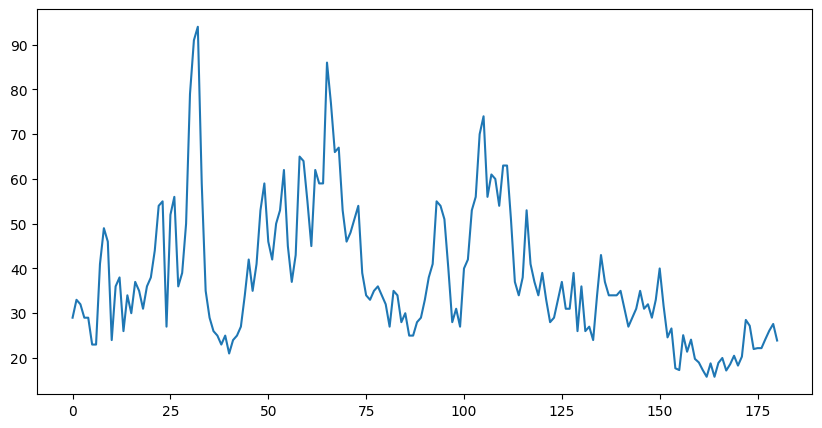

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df[station])

ไม่มี Missing เพราะ ถ้ามีค่า NaN matplotlib จะมีช่วงเส้นขาด

# 5) Outliers

## 5.1 Outlier คืออะไร (และทำไมต้องระวังคำว่า “ผิดปกติ”)

Outlier ในงาน DS มีได้ 2 แบบใหญ่

1. **Error Outlier (ผิดเพราะระบบ/ข้อมูลผิด)**

* ค่า PM2.5 = -5
* ค่า PM2.5 = 9999
* เกิดจาก sensor glitch / parsing error

2. **Real Extreme (เหตุการณ์จริงที่รุนแรง)**

* ช่วงไฟป่า/เผาในที่โล่ง
* ช่วงสภาพอากาศนิ่งมากจนฝุ่นสะสม

*ประเด็นสำคัญ:*
> Outlier ไม่ได้แปลว่า “ต้องลบ”  
> แต่คือ “ต้องอธิบาย” และ “ตัดสินใจบนหลักฐาน”

---

## 5.2 วิธีหา Outliers แบบต่าง ๆ

### วิธีที่ 1: Z-score (เหมาะเมื่อข้อมูลใกล้ Normal)

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20210525140711/empiricalrule-660x388.png">

*image from [Z-Score in Statistics | Definition, Formula, Calculation and Uses](https://www.geeksforgeeks.org/data-science/z-score-in-statistics/)*

**แนวคิด:** วัดว่าค่าอยู่ห่างจาก mean กี่ส่วนเบี่ยงเบนมาตรฐาน

สูตร:
# $z = \frac{x - \mu}{\sigma}$

เกณฑ์:
# $|z|$ > 3 (หรือ 2.5)

**ใช้เมื่อ:** distribution ใกล้ปกติ

**ข้อจำกัด:** ไม่ robust ต่อ skew/outliers (ตัวมันเองทำให้ σ บวม)

---

In [6]:
# Calculate Z-score
z = (df_all[station] - df_all[station].mean()) / df_all[station].std()
print(z)
# Filter for outliers
outliers_by_z = df_all[abs(z) > 3][station]
print(outliers_by_z)

0      -0.313472
1       0.061998
2       1.113315
3       1.714067
4       0.737845
          ...   
1272    0.925580
1273   -0.336000
1274   -0.666414
1275    0.092036
1276    0.204677
Name: 54T, Length: 1277, dtype: float64
13      77.0
14      93.0
15     106.0
19      78.0
20      82.0
21      92.0
22      90.0
31      74.0
37      78.0
355     75.0
463     79.0
760     79.0
761     91.0
762     94.0
795     86.0
796     77.0
835     74.0
940     74.6
941     78.0
955     83.0
Name: 54T, dtype: float64


In [7]:
outliers_by_z.shape

(20,)

### วิธีที่ 2: IQR (Tukey’s fences) — Robust และนิยมมาก

<img src="https://www.simplypsychology.org/wp-content/uploads/boxplot-outliers.png">

*image from [Reading a Box and Whisker Plot](https://www.simplypsychology.org/boxplots.html)*

คำนวณ:

* Q1, Q3
* IQR = Q3 - Q1
* upper = Q3 + 1.5 IQR
* lower = Q1 - 1.5 IQR

**ใช้เมื่อ:** distribution skew ได้, ต้องการ robustness

**ข้อจำกัด:** ถ้า time-series มี seasonality ควรทำแบบ “แยกช่วง/แยกกลุ่ม” ไม่งั้นฤดูหนักจริงจะโดน flag เยอะ

---

<Axes: >

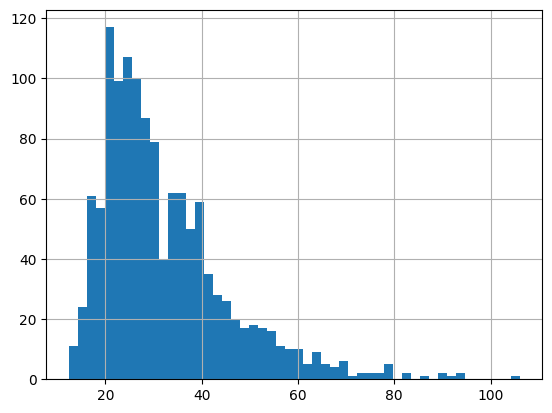

In [8]:
# ดูรูปการกระจายของของข้อมูล (Data Distribution)
df_all[station].hist(bins=50)

In [9]:
# หาค่า Q1 และ Q3
q1 = df_all[station].quantile(0.25)
q3 = df_all[station].quantile(0.75)
iqr = q3 - q1

# หาค่าขอบเขตล่าง และ ขอบเขตบน
upper_bound = q3 + 1.5 * iqr
lower_bound = q3 - 1.5 * iqr

# ดูข้อมูลที่คาดว่าจะเป็น Outliers
outliers_by_iqr = df_all[(df_all[station] > upper_bound) |  (df_all[station] < lower_bound)][station]
outliers_by_iqr

,54T
13,77.0
14,93.0
15,106.0
19,78.0
20,82.0
21,92.0
22,90.0
31,74.0
32,69.0
33,66.0


In [10]:
outliers_by_iqr.shape

(48,)

### วิธีที่ 3: Modified Z-score (Median + MAD) — Robust กว่า Z-score

แนวคิด: ใช้ median และ MAD (median absolute deviation)

คำนวณ:

# $MAD = median(|x - median(x)|)$

# $M = 0.6745 \cdot \frac{x - median(x)}{MAD}$

เกณฑ์:

# $|M|$ > 3.5

**ใช้เมื่อ:** skew มาก, ต้อง robust สูง

**ข้อจำกัด:** อธิบายยากกว่าสำหรับผู้เริ่มต้น

---

In [11]:
# หาค่า MAD
median = df_all[station].median()
mad = (df_all[station] - median).abs().median()

# หาค่า M
m = 0.6745 * (df_all[station] - median) / mad

# ดูข้อมูลที่คาดว่าจะเป็น Outliers
outliers_by_mad = df_all[abs(m) > 3.5][station]
outliers_by_mad

,54T
13,77.0
14,93.0
15,106.0
19,78.0
20,82.0
21,92.0
22,90.0
31,74.0
32,69.0
37,78.0


In [12]:
outliers_by_mad.shape

(30,)

### วิธีที่ 4: Percentile-based Rule (Quantile capping)

แนวคิด: กำหนดว่า outlier คือค่าที่เกิน P99 หรือ ต่ำกว่า P1

**ข้อดี**

* ง่ายมาก
* เหมาะกับการกำหนด “cap” สำหรับ visualization หรือ feature engineering

**ข้อจำกัด**

* เป็นการตัดสินใจเชิงนโยบาย (policy) มากกว่าเชิงสถิติ
* หากมีเหตุการณ์สุดโต่งจริง (เช่น episode วิกฤต) จะถูกตัดทิ้ง

**เหมาะใช้เมื่อ**

* ต้องการลดอิทธิพลค่าปลายเพื่อเสถียรภาพในการ train

---

In [13]:
# หาค่า P1 และ P99
p1 = df_all[station].quantile(0.01)
p99 = df_all[station].quantile(0.99)

# ดูข้อมูลที่คาดว่าจะเป็น Outliers
outliers_by_p = df_all[(df_all[station] < p1) | (df_all[station] > p99)][station]
outliers_by_p

,54T
14,93.0
15,106.0
20,82.0
21,92.0
22,90.0
108,13.0
199,14.0
285,14.0
463,79.0
505,13.0


In [14]:
outliers_by_p.shape

(23,)

### วิธีที่ 5: Time-series anomaly (Rolling statistics)

แนวคิด: เปรียบเทียบค่าปัจจุบันกับ baseline ในหน้าต่างเวลา

ตัวอย่าง กรณีใช้ Z-score:

* rolling_mean, rolling_std
* flag เมื่อ  
x > rolling_mean + k * rolling_std หรือ  
x < rolling_mean - k * rolling_std

**ข้อดี**

* เหมาะกับ time-series เพราะ “ความผิดปกติขึ้นกับบริบทเวลา”
* จับ spike แบบเฉพาะช่วงได้ดี

**ข้อจำกัด**

* ต้องเลือก window size และ k
* ถ้า window ครอบช่วงวิกฤต baseline จะสูงตาม

**เหมาะใช้เมื่อ**

* เป้าหมายคือจับ anomaly/spike ในลำดับเวลา

---

In [15]:
# คำนวณ rolling mean และ rolling std (เช่น window = 30 วัน)
rolling_mean = df_all[station].rolling(window=30).mean()
rolling_std = df_all[station].rolling(window=30).std()

# กำหนด threshold (เช่น k = 3)
upper_bound = rolling_mean + 3 * rolling_std
lower_bound = rolling_mean - 3 * rolling_std

# ดูข้อมูลที่คาดว่าจะเป็น Outliers
outliers_by_rolling = df_all[(df_all[station] > upper_bound) | (df_all[station] < lower_bound)][station]
outliers_by_rolling

,54T
194,33.0
340,51.0
355,75.0
462,58.0
463,79.0
608,38.0
609,43.0
760,79.0
761,91.0
919,63.3


- แต่ละวิธีให้จำนวน outliers เท่ากันหรือไม่
- วิธีใดที่เหมาะสมที่สุด เพราะอะไร
-	ค่าที่ถือว่า outlier ในบริบทนี้ เป็น error หรือเหตุการณ์จริง
-	หากใช้ข้อมูลเพื่อ
  - เตือนภัยประชาชน → outlier ยังเป็นปัญหาหรือไม่
  -	คำนวณค่าเฉลี่ยระยะยาว → มุมมองต่อ outlier เปลี่ยนหรือไม่


## 5.3 เปรียบเทียบแนวทาง

| วิธี          |    Robust ต่อ skew | เหมาะกับ Univariate | เหมาะกับ Time-series | ใช้เป็น “หลักฐาน” ได้ดีแค่ไหน |
| ------------- | -----------------: | ------------------: | -------------------: | ----------------------------- |
| Z-score       |                ต่ำ |                 สูง |                  ต่ำ | ปานกลาง                       |
| IQR           |                สูง |                 สูง |              ปานกลาง | สูง                           |
| MAD           |             สูงมาก |                 สูง |              ปานกลาง | สูงมาก                        |
| Percentile    |            ปานกลาง |                 สูง |                  ต่ำ | ปานกลาง (policy-driven)       |
| Rolling       | ขึ้นกับพารามิเตอร์ |             ปานกลาง |               สูงมาก | สูง (ถ้าอธิบาย baseline ดี)   |
<br>

*แนวทางปฏิบัติ:*
> * เริ่มจาก **IQR** และ **Rolling anomaly**
> * ถ้าข้อมูล skew มาก ใช้ **MAD** เพิ่ม
> * Z-score ให้เป็นตัวอย่าง แต่ไม่ใช่ default

---

# 6) Bias


## 6.1 Bias คืออะไรในมุม Data Science

**Bias** ในที่นี้หมายถึง “ข้อมูลเป็นตัวแทนของโลกจริงแบบไม่สมดุล” จนทำให้การสรุป/แบบจำลอง **เอนเอียง** ไปทางบางกลุ่มหรือบางสถานการณ์

* Bias ไม่จำเป็นต้องเกิดจากเจตนา (malicious intent)
* Bias มักเกิดจาก “วิธีเก็บข้อมูล” และ “ขอบเขตของระบบ”

---

## 6.2 ประเภทของ Bias ที่พบบ่อย

### (1) Selection Bias (อคติจากการเลือกกลุ่มตัวอย่าง)

**สาเหตุ**

* เก็บข้อมูลจากบางพื้นที่/บางสาขา/บางช่วงเวลา
* อุปกรณ์วัดมีเฉพาะบางจุด
* เลือกเฉพาะข้อมูลที่เข้าถึงง่าย

**ผลกระทบ**

* สรุปผลแล้วเหมือน “เป็นความจริงทั่วไป” แต่จริง ๆ ใช้ได้แค่บางกลุ่ม
* โมเดลจะทำงานดีเฉพาะกลุ่มที่ถูกเก็บข้อมูลเยอะ

**ตัวอย่างทั่วไป**

* วิเคราะห์พฤติกรรมลูกค้าโดยใช้เฉพาะลูกค้าที่สมัครสมาชิก → มองไม่เห็นลูกค้าขาจร

---


### (2) Measurement Bias (อคติจากการวัด/เครื่องมือ)

**สาเหตุ**

* sensor/เครื่องมือมีความไวต่างกัน
* ความคลาดเคลื่อนจากการสอบเทียบ (calibration)
* วิธีวัดไม่เหมือนกันระหว่างแหล่งข้อมูล

**ผลกระทบ**

* สรุปผิดว่า “กลุ่มนี้มีค่าสูงกว่า” ทั้งที่จริงเป็นเพราะเครื่องมือวัดต่างกัน
* โมเดลเรียนรู้ความต่างของ “เครื่องวัด” แทน “ปรากฏการณ์จริง”

---


### (3) Survivorship Bias (เห็นเฉพาะสิ่งที่เหลือรอด)

**สาเหตุ**

* ข้อมูลที่หายไป/ไม่ถูกบันทึก “ไม่ถูกนำมาคิด”
* ระบบเก็บเฉพาะเคสที่ผ่านขั้นตอนหนึ่งแล้ว

**ผลกระทบ**

* ประเมินความเสี่ยงต่ำกว่าจริง เพราะเคสที่ล้มเหลวหายไปจากข้อมูล
* สรุปว่า “ทุกอย่างปกติดี” เพราะเห็นเฉพาะเหตุการณ์ที่ถูกบันทึกสำเร็จ

---


### (4) Temporal Bias (อคติด้านเวลา / non-stationarity)

**สาเหตุ**

* เก็บข้อมูลเฉพาะบางฤดูกาล/บางไตรมาส
* เหตุการณ์เปลี่ยน (policy, economy, behavior) ทำให้ pattern เปลี่ยน

**ผลกระทบ**

* โมเดล/ข้อสรุปใช้กับอนาคตไม่ได้
* การเปรียบเทียบข้ามช่วงเวลาอาจไม่แฟร์

---


### (5) Missingness-induced Bias (อคติที่เกิดจาก missing)

**สาเหตุ**

* Missing แบบ MAR/MNAR ทำให้ข้อมูลหาย “เฉพาะบางเงื่อนไข” หรือ “เฉพาะค่าบางช่วง”

**ผลกระทบ**

* ค่าเฉลี่ยและ distribution เพี้ยน
* ความสัมพันธ์ระหว่างตัวแปรผิด
* เหตุการณ์สำคัญถูกซ่อนไว้

---


## 6.3 วิธี “ตรวจจับ bias” ในช่วง Data Understanding

แนวทางตรวจจับแบบเป็นระบบ:

1. **Coverage Check**

* เรามีข้อมูลครอบคลุม “ใคร/ที่ไหน/เมื่อไร” แค่ไหน
* ดูสัดส่วน record ตามกลุ่ม (พื้นที่/ช่วงเวลา/ประเภท)

2. **Group-wise Summary**

* สรุปสถิติแยกกลุ่ม (mean/median/percentiles)
* ถ้าต่างกันมากผิดปกติ ให้ถามว่า “เป็นปรากฏการณ์จริง หรือเครื่องมือ/การเก็บต่างกัน”

3. **Missing Pattern by Group**

* missing มากในกลุ่มไหน ช่วงไหน
* ถ้า missing กระจุก → เสี่ยง MAR/MNAR → bias สูง

4. **Compare to External Expectation (Domain sanity check)**

* ค่าที่ “ควรจะเป็น” ตามสามัญสำนึกหรือความรู้โดเมน
* ถ้าขัดแย้ง → มี bias หรือ quality issue

---

# 7) Business Understanding ↔ Data Understanding

## 7.1 หลักการสำคัญ

ความสัมพันธ์เป็น “สองทาง”:

* **Business Understanding → Data Understanding**
  คำถามธุรกิจจะกำหนดว่าเราต้องตรวจอะไรในข้อมูล

* **Data Understanding → Business Understanding**
  ข้อจำกัดของข้อมูลจะบังคับให้เราปรับคำถามธุรกิจให้ realistic

---


## 7.2 Business → Data: คำถามธุรกิจแปลเป็น “สิ่งที่ต้องตรวจในข้อมูล” อย่างไร

ตัวอย่างแนวคิด:

1. ถ้าคำถามคือ “แนวโน้มตามเวลา”  
   → ต้องตรวจ temporal completeness, time gaps, timezone, granularity

2. ถ้าคำถามคือ “เปรียบเทียบระหว่างพื้นที่/กลุ่ม”  
   → ต้องตรวจ coverage, selection bias, consistency ของกลุ่ม/รหัส

3. ถ้าคำถามคือ “หาความสัมพันธ์/ปัจจัย”  
   → ต้องตรวจ missing mechanism (MAR/MNAR), outlier meaning, measurement bias

4. ถ้าคำถามคือ “พยากรณ์/ทำนาย”  
   → ต้องตรวจ drift ตามเวลา, leakage จากตัวแปรที่ไม่ควรรู้ในขณะทำนาย

---


## 7.3 Data → Business: เมื่อข้อมูลมีข้อจำกัด ควรปรับโจทย์อย่างไร

“ข้อจำกัดของข้อมูล” มีผลต่อ “ขอบเขตคำตอบ” เสมอ

ตัวอย่างรูปแบบการปรับโจทย์:

* โจทย์เดิม: “หาปัจจัยที่ทำให้เกิด X” (เชิงเหตุ-ผล)  
  ถ้าข้อมูลเป็น observational และมี bias สูง  
  → ปรับเป็น: “หาความสัมพันธ์ที่สอดคล้องกับ X และอภิปรายข้อจำกัด”

* โจทย์เดิม: “เปรียบเทียบทุกพื้นที่”  
  ถ้าข้อมูลมีเฉพาะบางพื้นที่  
  → ปรับเป็น: “เปรียบเทียบเฉพาะพื้นที่ที่ครอบคลุม และระบุสิ่งที่ขาดหาย”

* โจทย์เดิม: “พยากรณ์ระยะยาว”  
  ถ้าข้อมูลมีแค่ช่วงสั้น/มีเหตุการณ์เปลี่ยนระบบ  
  → ปรับเป็น: “พยากรณ์ระยะสั้น/ทำ scenario analysis”

---

## 7.4 Exploratory Data Analysis (EDA) vs. Data Understanding

### Exploratory Data Analysis (EDA)
- **แนวคิดหลัก:** เป็นการสำรวจข้อมูลเชิงสถิติและภาพ เพื่อ “ทำความเข้าใจว่าเกิดอะไรขึ้นในข้อมูล”  
- **กิจกรรมสำคัญ:**
  - ใช้กราฟ/สถิติพื้นฐานเพื่อดูการกระจาย, ความสัมพันธ์, ความผิดปกติ
  - ทดลองหลายรูปแบบการแสดงผล (scatter plot, histogram, boxplot ฯลฯ)
  - ค้นหา pattern, outlier, หรือ insight ที่ไม่คาดคิด
- **บทบาท:** เป็นเครื่องมือเชิงวิจัยและการเรียนรู้ข้อมูล ใช้ได้ทั้งในงานวิชาการและงานจริง  
- **จุดเด่น:** เน้นความคิดสร้างสรรค์และการตีความ ไม่จำกัดขั้นตอนตายตัว

---

### Data Understanding (CRISP-DM)
- **แนวคิดหลัก:** เป็น **ขั้นตอนที่ 2** ของกระบวนการ CRISP-DM (Cross Industry Standard Process for Data Mining)  
- **กิจกรรมสำคัญ:**
  - รวบรวมข้อมูลจากหลายแหล่ง
  - ตรวจสอบคุณภาพข้อมูล (missing values, consistency, completeness)
  - สร้างรายงานเบื้องต้น เช่น ขนาดข้อมูล, จำนวนแถว/คอลัมน์, ประเภทตัวแปร
  - ระบุปัญหาที่อาจเกิดขึ้น เช่น bias, noise, หรือข้อจำกัดของข้อมูล
- **บทบาท:** เป็นขั้นตอนเชิงกระบวนการที่มีโครงสร้างชัดเจน เพื่อเตรียมข้อมูลสำหรับการทำ Data Preparation และ Modeling  
- **จุดเด่น:** เน้นความเป็นระบบและการจัดการคุณภาพข้อมูล

---

### เปรียบเทียบ EDA กับ Data Understanding

| ด้าน | EDA | Data Understanding (CRISP-DM) |
|------|-----|--------------------------------|
| **เป้าหมาย** | ค้นหา pattern และ insight | ทำความเข้าใจคุณภาพและโครงสร้างข้อมูล |
| **ลักษณะงาน** | เชิงสำรวจ, ใช้ visualization และสถิติ | เชิงกระบวนการ, ตรวจสอบและบันทึกข้อมูล |
| **ความยืดหยุ่น** | เปิดกว้าง, ไม่ตายตัว | มีขั้นตอนชัดเจนใน framework |
| **ผลลัพธ์** | Insight, hypothesis, แนวคิดใหม่ | รายงานคุณภาพข้อมูล, ข้อจำกัด, metadata |
| **ตำแหน่งใน workflow** | ใช้ได้หลายจุด (ก่อน/ระหว่าง/หลัง modeling) | ขั้นตอนที่ 2 ของ CRISP-DM |

---

สรุป:  
- **EDA** = เครื่องมือเชิงสำรวจเพื่อ “เล่นกับข้อมูล” และค้นหา insight  
- **Data Understanding (CRISP-DM)** = ขั้นตอนเชิงกระบวนการเพื่อ “ตรวจสอบและบันทึกคุณภาพข้อมูล”
- สามารถใช้เสริมกันได้
> Data Understanding ให้โครงสร้างและความมั่นใจในข้อมูล  
> EDA เปิดพื้นที่ให้เราเจอสิ่งที่ไม่คาดคิดและสร้างสมมติฐานใหม่ ๆ  

---

# Hand-on Practice
ทำใน notebook

## Task 1: Data Type & Semantic Type (PM2.5)

* อธิบาย Data Type และ Semantic Type:

| คอลัมน์ | Data Type | Semantic Type |
|-------|-----------|---------------|
| Date |Object (เป็นข้อความที่มีรูปแบบวันเวลา สามารถแปลงเป็น DateTime ได้)            |Temporal ข้อมูลที่บอกช่วงเวลาหรือจุดเวลา               |
| station |Object (เป็นรหัสสถานี เช่น Txxx มีตัวอักษรผสมตัวเลข)         |Identifier ใช้ระบุเอกลักษณ์ของแต่ละสถานี               |


## Task 2: Missing Data Profiling

* สรุป missing ต่อสถานี (แยกสถานีที่มี missing น้อย, ปานกลาง และ มาก)
* สรุป missing ต่อช่วงเวลา (เช่น รายเดือน/รายสัปดาห์)
* missing น่าจะเป็นแบบไหน (MCAR/MAR/MNAR) เพราะอะไร


In [27]:
# สรุป missing ต่อสถานี
missing_percent = df.isna().mean() * 100

def classify_missing(p):
    if p == 0:
        return "ไม่มี Missing"
    elif p < 5:
        return "น้อย"
    elif p < 20:
        return "กลาง"
    else:
        return "มาก"

missing_summary = missing_percent.to_frame(name="Missing %")
missing_summary["ระดับ"] = missing_summary["Missing %"].apply(classify_missing)

missing_summary

,Missing %,ระดับ
02T,1.104972,น้อย
05T,1.104972,น้อย
10T,3.314917,น้อย
11T,0.000000,ไม่มี Missing
12T,3.867403,น้อย
...,...,...
63T,20.441989,มาก
78T,0.000000,ไม่มี Missing
80T,0.000000,ไม่มี Missing
89T,0.000000,ไม่มี Missing


In [23]:
# สรุป missing ต่อช่วงเวลา
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

In [24]:
monthly_missing = df.isna().resample("M").mean() * 100
monthly_missing

/tmp/ipython-input-319/3906158846.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_missing = df.isna().resample("M").mean() * 100


,02T,05T,10T,11T,12T,59T,61T,03T,50T,52T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-31,0.000000,0.000000,0.000000,0.0,0.000000,0.0,9.677419,0.000000,100.000000,0.0,...,0.0,3.225806,51.612903,3.225806,100.000000,100.000000,0.0,0.0,0.0,0.000000
2023-02-28,7.142857,7.142857,14.285714,0.0,17.857143,0.0,0.000000,7.142857,7.142857,0.0,...,0.0,10.714286,0.000000,3.571429,14.285714,14.285714,0.0,0.0,0.0,0.000000
2023-03-31,0.000000,0.000000,6.451613,0.0,0.000000,0.0,0.000000,6.451613,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
2023-04-30,0.000000,0.000000,0.000000,0.0,3.333333,0.0,0.000000,6.666667,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,6.666667,0.0,0.0,0.0,3.333333
2023-05-31,0.000000,0.000000,0.000000,0.0,3.225806,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,6.451613,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,6.451613
2023-06-30,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


In [25]:
weekly_missing = df.isna().resample("W").mean() * 100
weekly_missing

,02T,05T,10T,11T,12T,59T,61T,03T,50T,52T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,100.000000,0.0,...,0.0,0.000000,0.000000,0.000000,100.000000,100.000000,0.0,0.0,0.0,0.000000
2023-01-08,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,100.000000,0.0,...,0.0,0.000000,0.000000,0.000000,100.000000,100.000000,0.0,0.0,0.0,0.000000
2023-01-15,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,100.000000,0.0,...,0.0,0.000000,0.000000,0.000000,100.000000,100.000000,0.0,0.0,0.0,0.000000
2023-01-22,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,100.000000,0.0,...,0.0,14.285714,100.000000,14.285714,100.000000,100.000000,0.0,0.0,0.0,0.000000
2023-01-29,0.000000,0.000000,0.000000,0.0,0.000000,0.0,42.857143,0.000000,100.000000,0.0,...,0.0,0.000000,100.000000,0.000000,100.000000,100.000000,0.0,0.0,0.0,0.000000
2023-02-05,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,57.142857,0.0,...,0.0,42.857143,28.571429,0.000000,85.714286,85.714286,0.0,0.0,0.0,0.000000
2023-02-12,0.000000,0.000000,0.000000,0.0,28.571429,0.0,0.000000,28.571429,0.000000,0.0,...,0.0,0.000000,0.000000,14.285714,0.000000,0.000000,0.0,0.0,0.0,0.000000
2023-02-19,0.000000,28.571429,0.000000,0.0,42.857143,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
2023-02-26,28.571429,0.000000,42.857143,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


Missing น่าจะเป็นแบบ MCAR และ MAR เพราะค่าฝุ่นอาจหายแบบสุ่ม เช่น เครื่องตรวจพัง หรือเกิดจากตัวแปรอื่น เช่น มีการก่อสร้างบริเวณนั้น เลยมีฝุ่นเยอะ

## Task 3: Outlier Detection Comparison

ให้ผู้เรียนคำนวณหา outliers แบบ Rolling statistics ด้วย window_size 7, 15 เปรียบเทียบกับ 30 เพื่อทดสอบว่า

* window_size มีผลต่อ outliers ที่ได้หรือไม่ อย่างไร


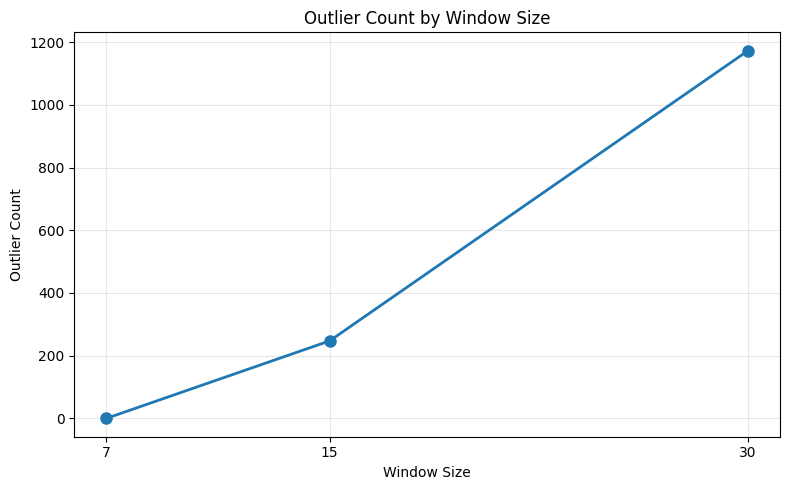

In [34]:
exclude = ["Mean", "DayNull", "Date"]
cols = [c for c in df_all.columns if c not in exclude]

rawData_outlier = {}
to_bar = []

window_size = [7, 15, 30]

for j in window_size:
    total_outliers = 0

    for i in cols:
        rm = df_all[i].rolling(window=j, min_periods=j)
        mean = rm.mean()
        std = rm.std()

        mask = df_all[i].sub(mean).abs() > 3 * std
        total_outliers += mask.sum()

    rawData_outlier[j] = total_outliers
    to_bar.append(total_outliers)

plt.figure(figsize=(8, 5))
plt.plot(window_size, to_bar, marker='o', linewidth=2, markersize=8)
plt.title("Outlier Count by Window Size")
plt.xlabel("Window Size")
plt.ylabel("Outlier Count")
plt.xticks(window_size)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

มีผล เพราะ การที่ Window Size ยิ่งใหญ่ก็จะสามารถเก็บ Outlier ได้มากขึ้น

## Task 4: Business Understanding ↔ Data Understanding

ตั้งคำถามทางธุรกิจ (Business Understanding) ที่สอดคล้องกับการทำ Data Understanging อย่างน้อย 2 คำถาม

---

1. ช่วงเวลาใดที่ค่า PM2.5 สูงผิดปกติจนควรแจ้งเตือนผู้อื่น
2. ควรออกนโยบายควบคุมมลพิษทางอากาศให้แก่สถานีใดบ้าง

# 9) Deliverable Checklist

ก่อนส่งงาน โปรดตรวจสอบว่า:

- [ ] Notebook รันได้ครบทุก cell และไม่มี error  
- [ ] ทำ Hand-on ครบ (Task 1–4)  
- [ ] Download .ipynb ตั้งชื่อไฟล์ *[รหัสนักศึกษา]_Lab3.ipynb*
- [ ] ส่งใน **งานในชั้นเรียน > "Lab 3"**